In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import glob
import os
import io

path = '/content/drive/MyDrive/Colab Notebooks/Sheryar/Training'

csv_files = glob.glob(os.path.join(path, "*.csv"))

data_dict = {}
target_cols = ['File X', 'File Y', 'B1', 'B2', 'B3', 'B4']

for f in csv_files:
    df_name = os.path.splitext(os.path.basename(f))[0]
    print(f"Processing: {df_name}")

    try:
        with open(f, 'r') as file:
            lines = file.readlines()

        header_line = lines[7].lstrip(';').strip()
        data_lines = [line.strip() for line in lines[9:]]

        csv_content = "\n".join([header_line] + data_lines)

        df = pd.read_csv(io.StringIO(csv_content), sep=',', skipinitialspace=True)

        available_cols = [col for col in target_cols if col in df.columns]
        data_dict[df_name] = df[available_cols]

        print(f"  Successfully loaded {df_name} with shape: {data_dict[df_name].shape}")
        if not data_dict[df_name].empty:
             display(data_dict[df_name].head(2))
    except Exception as e:
        print(f"  Error processing {f}: {e}")

print(f"\nCreated {len(data_dict)} separate DataFrames.")

Processing: urban
  Successfully loaded urban with shape: (495553, 6)


,File X,File Y,B1,B2,B3,B4
0,4273,745,298,332,261,263
1,4272,746,305,343,271,272


Processing: water
  Successfully loaded water with shape: (386814, 6)


,File X,File Y,B1,B2,B3,B4
0,7517,397,235,251,186,185
1,7518,398,236,250,187,177


Processing: road
  Successfully loaded road with shape: (69203, 6)


...

Processing: cpf-253
  Successfully loaded cpf-253 with shape: (133030, 6)


,File X,File Y,B1,B2,B3,B4
0,6951,2400,244,262,189,243
1,6950,2401,244,263,188,247


Processing: sl-284
  Successfully loaded sl-284 with shape: (232509, 6)


,File X,File Y,B1,B2,B3,B4
0,6823,2334,247,261,188,257
1,6824,2335,251,266,191,263



Created 5 separate DataFrames.


In [ ]:
import pandas as pd
import numpy as np

neighbor_datasets = {}

for name, df in data_dict.items():
    print(f"Finding neighbors for: {name}...")

    df_indexed = df.set_index(['File X', 'File Y']).sort_index()
    df_indexed = df_indexed[~df_indexed.index.duplicated(keep='first')]

    band_cols = ['B1', 'B2', 'B3', 'B4']
    all_neighbor_data = []

    shifts = [(-1, -1), (0, -1), (1, -1),
              (-1,  0), (0,  0), (1,  0),
              (-1,  1), (0,  1), (1,  1)]

    neighbor_frames = []
    for dx, dy in shifts:
        shifted = df_indexed.copy()
        shifted.index = pd.MultiIndex.from_tuples(
            [(x - dx, y - dy) for x, y in shifted.index],
            names=['File X', 'File Y']
        )
        suffix = f"_{dx}_{dy}" if (dx, dy) != (0,0) else "_center"
        shifted.columns = [f"{col}{suffix}" for col in shifted.columns]
        neighbor_frames.append(shifted)

    result_df = pd.concat(neighbor_frames, axis=1, join='inner')

    result_df = result_df.reset_index()

    neighbor_datasets[name] = result_df
    print(f"  Done. Resulting shape for {name}: {result_df.shape}")

first_key = list(neighbor_datasets.keys())[0]
display(neighbor_datasets[first_key].head())

Finding neighbors for: urban...
  Done. Resulting shape for urban: (486975, 38)
Finding neighbors for: water...
  Done. Resulting shape for water: (355062, 38)
Finding neighbors for: road...
  Done. Resulting shape for road: (43267, 38)
Finding neighbors for: cpf-253...
  Done. Resulting shape for cpf-253: (125130, 38)
Finding neighbors for: sl-284...
  Done. Resulting shape for sl-284: (220829, 38)


,File X,File Y,B1_-1_-1,B2_-1_-1,B3_-1_-1,B4_-1_-1,B1_0_-1,B2_0_-1,B3_0_-1,B4_0_-1,...,B3_-1_1,B4_-1_1,B1_0_1,B2_0_1,B3_0_1,B4_0_1,B1_1_1,B2_1_1,B3_1_1,B4_1_1
0,3985,935,298,341,269,270,302,349,276,275,...,275,280,306,358,281,285,306,353,279,284
1,3985,936,301,347,273,276,302,350,277,277,...,274,279,310,359,283,286,304,350,278,282
2,3986,935,302,349,276,275,314,360,286,286,...,281,285,306,353,279,284,307,352,280,286
3,3986,936,302,350,277,277,308,355,281,285,...,283,286,304,350,278,282,303,346,276,281
4,3986,937,306,358,281,285,306,353,279,284,...,281,283,310,354,282,284,306,348,278,282


In [ ]:
import pandas as pd
class_mapping = {'cpf-253': 0, 'road': 1, 'sl-284': 2, 'urban': 3, 'water': 4}

all_dfs = []

for name, df in neighbor_datasets.items():
    if name in class_mapping:
        if name != 'road':
          temp_df = df.head(250000).copy()

        else:
          temp_df = df.copy()

        temp_df['class'] = class_mapping[name]

        cols_to_drop = [c for c in ['File X', 'File Y'] if c in temp_df.columns]
        temp_df = temp_df.drop(columns=cols_to_drop)

        all_dfs.append(temp_df)
        print(f"Added {name} to stack with class label {class_mapping[name]}")

final_df = pd.concat(all_dfs, ignore_index=True)

print(f"\nFinal stacked dataframe shape: {final_df.shape}")
print("Class distribution:")
print(final_df['class'].value_counts())

display(final_df.head())

Added urban to stack with class label 3
Added water to stack with class label 4
Added road to stack with class label 1
Added cpf-253 to stack with class label 0
Added sl-284 to stack with class label 2

Final stacked dataframe shape: (889226, 37)
Class distribution:
class
3    250000
4    250000
2    220829
0    125130
1     43267
Name: count, dtype: int64


,B1_-1_-1,B2_-1_-1,B3_-1_-1,B4_-1_-1,B1_0_-1,B2_0_-1,B3_0_-1,B4_0_-1,B1_1_-1,B2_1_-1,...,B4_-1_1,B1_0_1,B2_0_1,B3_0_1,B4_0_1,B1_1_1,B2_1_1,B3_1_1,B4_1_1,class
0,298,341,269,270,302,349,276,275,314,360,...,280,306,358,281,285,306,353,279,284,3
1,301,347,273,276,302,350,277,277,308,355,...,279,310,359,283,286,304,350,278,282,3
2,302,349,276,275,314,360,286,286,320,363,...,285,306,353,279,284,307,352,280,286,3
3,302,350,277,277,308,355,281,285,314,359,...,286,304,350,278,282,303,346,276,281,3
4,306,358,281,285,306,353,279,284,307,352,...,283,310,354,282,284,306,348,278,282,3


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

INPUT_DIM = 4
NUM_LAYERS = 1
NHEAD = 4
DIM_FEEDFORWARD = 64
DROPOUT = 0.1
BATCH_SIZE = 256
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
RANDOM_STATE = 42

X = final_df.drop(columns=['class']).values
y = final_df['class'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_reshaped = X.reshape(-1, 9, INPUT_DIM).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded)

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class ContextAwareTransferTransformerClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, num_layers=NUM_LAYERS, nhead=NHEAD, dim_feedforward=DIM_FEEDFORWARD, dropout=DROPOUT):
        super(ContextAwareTransferTransformerClassifier, self).__init__()
        self.embedding = nn.Linear(input_dim, dim_feedforward)
        encoder_layers = nn.TransformerEncoderLayer(d_model=dim_feedforward, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(dim_feedforward, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.fc(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(le.classes_)
model = ContextAwareTransferTransformerClassifier(input_dim=INPUT_DIM, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def evaluate(loader, set_name, print_report=True):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(all_labels, all_preds)

    if print_report:
        print(f"\n--- {set_name} Classification Report ---")
        inverse_class_map = {v: k for k, v in class_mapping.items()} # Use the global class_mapping from earlier cells
        target_names = [inverse_class_map[cls_val] for cls_val in le.classes_]
        print(classification_report(all_labels, all_preds, target_names=target_names))
        print(f"Overall Accuracy: {accuracy:.4f}") # Explicitly print overall accuracy

    return accuracy, all_preds

train_losses = []
train_accuracies = []
test_accuracies = []

print(f"Starting training on {device}...")
model.train()
for epoch in range(NUM_EPOCHS):
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_accuracy = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.4f}")

    test_acc, _ = evaluate(test_loader, "Test Set (Epoch End)", print_report=False)
    test_accuracies.append(test_acc)

print("\n--- Final Evaluation ---")
final_train_accuracy, _ = evaluate(train_loader, "Final Training Set")
final_test_accuracy, test_preds = evaluate(test_loader, "Final Test Set")

Starting training on cuda...
Epoch 1/20, Train Loss: 0.2819, Train Accuracy: 0.8882
Epoch 2/20, Train Loss: 0.1896, Train Accuracy: 0.9208
Epoch 3/20, Train Loss: 0.1742, Train Accuracy: 0.9265
Epoch 4/20, Train Loss: 0.1658, Train Accuracy: 0.9294
Epoch 5/20, Train Loss: 0.1613, Train Accuracy: 0.9310
Epoch 6/20, Train Loss: 0.1565, Train Accuracy: 0.9329
Epoch 7/20, Train Loss: 0.1529, Train Accuracy: 0.9340
Epoch 8/20, Train Loss: 0.1503, Train Accuracy: 0.9351
Epoch 9/20, Train Loss: 0.1472, Train Accuracy: 0.9364
Epoch 10/20, Train Loss: 0.1469, Train Accuracy: 0.9365
Epoch 11/20, Train Loss: 0.1452, Train Accuracy: 0.9374
Epoch 12/20, Train Loss: 0.1442, Train Accuracy: 0.9376
Epoch 13/20, Train Loss: 0.1430, Train Accuracy: 0.9380
Epoch 14/20, Train Loss: 0.1418, Train Accuracy: 0.9386
Epoch 15/20, Train Loss: 0.1412, Train Accuracy: 0.9390
Epoch 16/20, Train Loss: 0.1406, Train Accuracy: 0.9391
Epoch 17/20, Train Loss: 0.1392, Train Accuracy: 0.9396
Epoch 18/20, Train Loss: 0.1

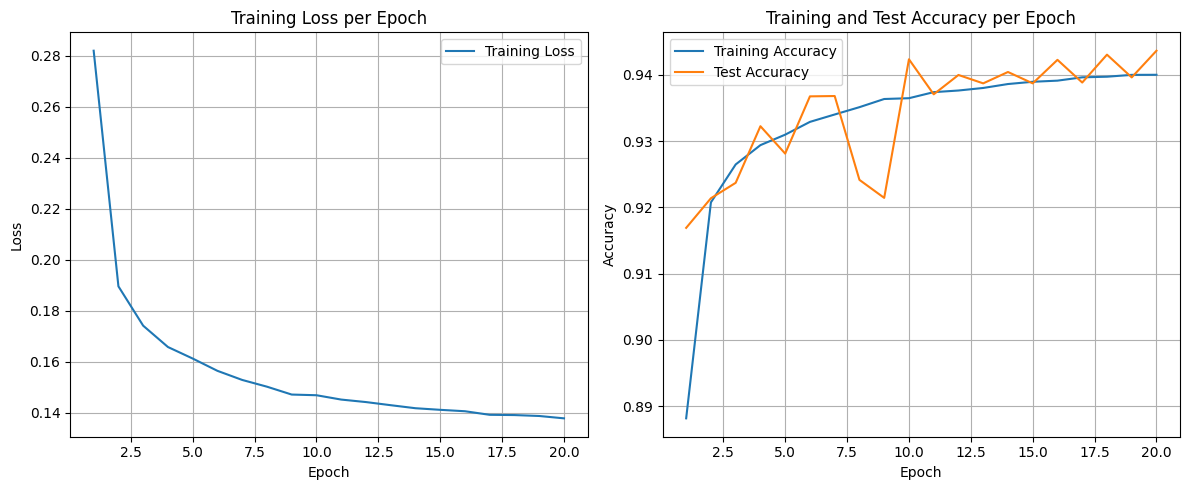


Final Training Accuracy: 0.9431
Final Test Accuracy: 0.9436


In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.title('Training and Test Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy:.4f}")

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

inverse_class_map = {v: k for k, v in class_mapping.items()}
target_names = [inverse_class_map[cls_val] for cls_val in le.classes_]

cm = confusion_matrix(y_test, test_preds)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

print("\n--- Test Set Confusion Matrix ---")
print(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()